# MNIST Digit Classification


## Step 1: Import Libraries and Load Data


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load MNIST training and test datasets


In [27]:
# Define transformations for the images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean and std
])

# Load the training dataset
train_dataset = datasets.MNIST(
    root='./data',  # Where to store the dataset
    train=True,     # This is training data
    download=True,  # Download if not present
    transform=transform  # Apply transformations
)

# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

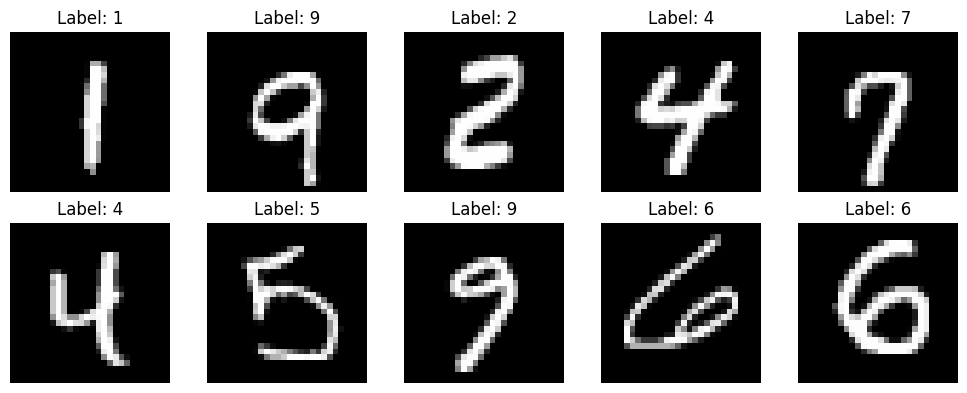

In [28]:
# Function to display images
def show_images(images, labels):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
show_images(images[:10], labels[:10])

## Step 2: Create a Simple Fully Connected Neural Network


In [29]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Initialize the model
model = SimpleNN()
print(model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## Step 3: Training the Neural Network : SimpleFCN

In [30]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Training loop
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
            train_losses.append(running_loss/100)
            running_loss = 0.0

print('Training finished!')

Using device: cpu
Epoch [1/5], Step [100/938], Loss: 1.0662
Epoch [1/5], Step [200/938], Loss: 0.3666
Epoch [1/5], Step [300/938], Loss: 0.3280
Epoch [1/5], Step [400/938], Loss: 0.2704
Epoch [1/5], Step [500/938], Loss: 0.2258
Epoch [1/5], Step [600/938], Loss: 0.2058
Epoch [1/5], Step [700/938], Loss: 0.1865
Epoch [1/5], Step [800/938], Loss: 0.1679
Epoch [1/5], Step [900/938], Loss: 0.1535
Epoch [2/5], Step [100/938], Loss: 0.1358
Epoch [2/5], Step [200/938], Loss: 0.1328
Epoch [2/5], Step [300/938], Loss: 0.1306
Epoch [2/5], Step [400/938], Loss: 0.1121
Epoch [2/5], Step [500/938], Loss: 0.1106
Epoch [2/5], Step [600/938], Loss: 0.1183
Epoch [2/5], Step [700/938], Loss: 0.1168
Epoch [2/5], Step [800/938], Loss: 0.1110
Epoch [2/5], Step [900/938], Loss: 0.0986
Epoch [3/5], Step [100/938], Loss: 0.0837
Epoch [3/5], Step [200/938], Loss: 0.0804
Epoch [3/5], Step [300/938], Loss: 0.0925
Epoch [3/5], Step [400/938], Loss: 0.0814
Epoch [3/5], Step [500/938], Loss: 0.0746
Epoch [3/5], Ste

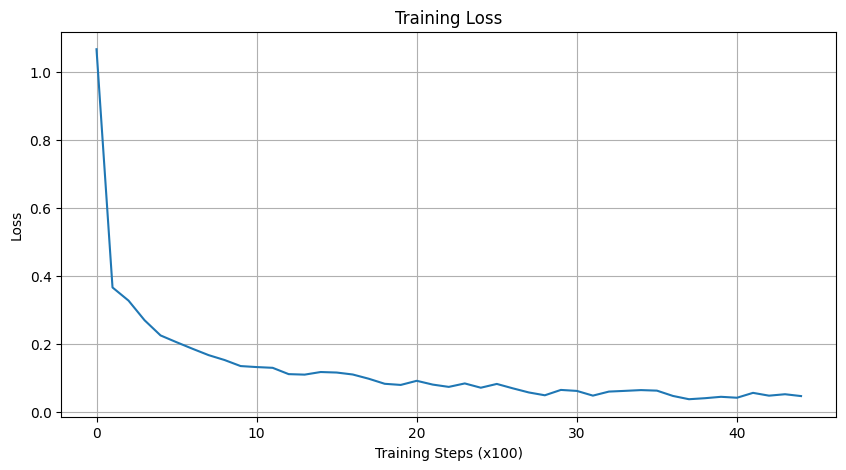

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Training Steps (x100)')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Step 4: Evaluating the Model

In [32]:
def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
    return y_true, y_pred

FCN Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.98      0.95      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.99      0.97       892
           6       0.99      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

FCN Confusion Matrix:



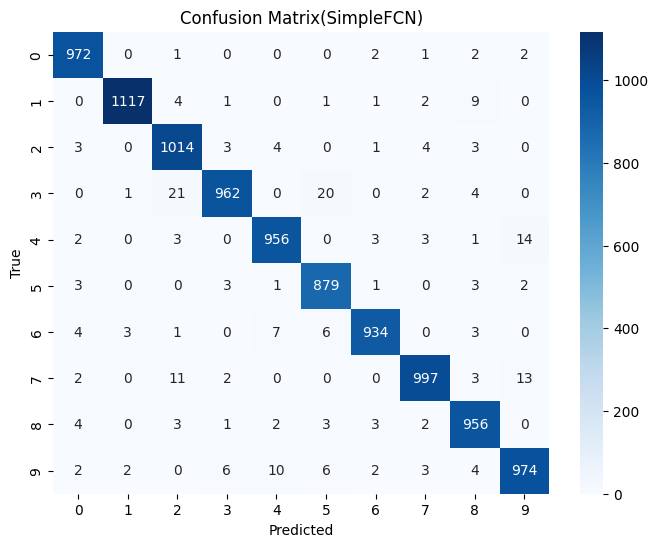

In [33]:
import seaborn as sns
y_true, y_pred = evaluate_model(model, test_loader)
print("FCN Classification Report:\n")
print(classification_report(y_true, y_pred))
print("FCN Confusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix(SimpleFCN)")
plt.show()

## Step 5: Simple Convolutional Neural Network
- While our simple neural network works reasonably well, convolutional neural networks (CNNs) are typically better for image processing tasks:

In [34]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 32 * 7 * 7)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN().to(device)

## Step 6: Training the Convolutional Neural Network : SimpleCNN

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model.parameters(), lr=0.01, momentum=0.9)

# Training loop
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
            train_losses.append(running_loss/100)
            running_loss = 0.0

print('Training finished!')

Epoch [1/5], Step [100/938], Loss: 1.1676
Epoch [1/5], Step [200/938], Loss: 0.2782
Epoch [1/5], Step [300/938], Loss: 0.1668
Epoch [1/5], Step [400/938], Loss: 0.1137
Epoch [1/5], Step [500/938], Loss: 0.1201
Epoch [1/5], Step [600/938], Loss: 0.1045
Epoch [1/5], Step [700/938], Loss: 0.0867
Epoch [1/5], Step [800/938], Loss: 0.0826
Epoch [1/5], Step [900/938], Loss: 0.0843
Epoch [2/5], Step [100/938], Loss: 0.0654
Epoch [2/5], Step [200/938], Loss: 0.0532
Epoch [2/5], Step [300/938], Loss: 0.0739
Epoch [2/5], Step [400/938], Loss: 0.0614
Epoch [2/5], Step [500/938], Loss: 0.0597
Epoch [2/5], Step [600/938], Loss: 0.0599
Epoch [2/5], Step [700/938], Loss: 0.0492
Epoch [2/5], Step [800/938], Loss: 0.0481
Epoch [2/5], Step [900/938], Loss: 0.0496
Epoch [3/5], Step [100/938], Loss: 0.0425
Epoch [3/5], Step [200/938], Loss: 0.0414
Epoch [3/5], Step [300/938], Loss: 0.0353
Epoch [3/5], Step [400/938], Loss: 0.0416
Epoch [3/5], Step [500/938], Loss: 0.0480
Epoch [3/5], Step [600/938], Loss:

## Step 6:  Evaluating the SimpleCNN

CNN Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.96      0.98       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

CCN Confusion Matrix:



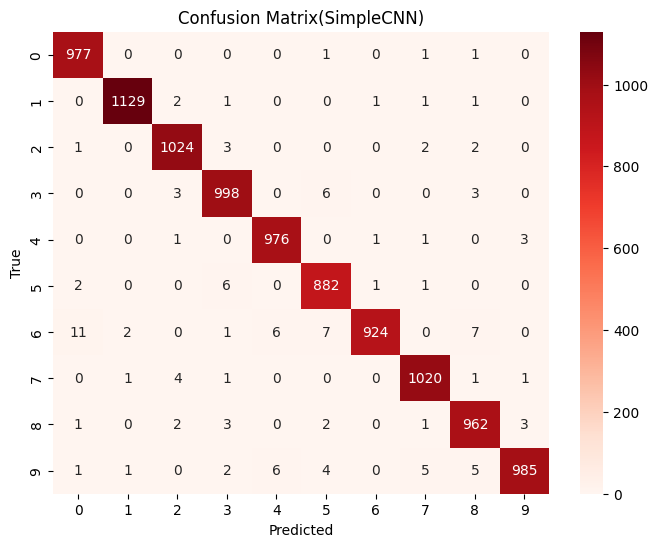

In [36]:
import seaborn as sns
y_true, y_pred = evaluate_model(cnn_model, test_loader)
print("CNN Classification Report:\n")
print(classification_report(y_true, y_pred))
print("CCN Confusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix(SimpleCNN)")
plt.show()

## Step 7: Compare Parameter Counts

In [37]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("FCN Parameters:", count_params(model))
print("CNN Parameters:", count_params(cnn_model))


FCN Parameters: 109386
CNN Parameters: 105866


## Summary of Results
- **Accuracy (FCN):** ~97%
- **Accuracy (CNN):** ~99%
- **MaxPool2D:** Reduces feature map size, helps focus on key patterns.
- **Conclusion:** CNN captures spatial features better than FCN. Despite having fewer parameters, CNN significantly outperforms FCN in accuracy.

## References

- [PyTorch MNIST Tutorial](https://pythonguides.com/pytorch-mnist/)
- [MaxPool2D Explanation](https://www.geeksforgeeks.org/computer-vision/apply-a-2d-max-pooling-in-pytorch/)
- [PyTorch MaxPool2D Docs](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)
